# STEP 3: Baseline 모델 (TF-IDF + LR / SVM)
법률 판례 텍스트 분류 — 팀 레옹

## 1단계: 라이브러리 로드 및 데이터 준비

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [3]:
# 데이터 로드
train = pd.read_csv('processed_data/train.csv')
val   = pd.read_csv('processed_data/val.csv')
test  = pd.read_csv('processed_data/test.csv')

# 라벨 이름 (숫자 → 카테고리명)
label_map = pd.read_csv('processed_data/label_mapping.csv')
label_names = label_map.sort_values('label')['class_name'].tolist()

print(f"Train: {len(train)}건 | Val: {len(val)}건 | Test: {len(test)}건")
print(f"라벨 종류: {label_names}")

Train: 34080건 | Val: 4260건 | Test: 4261건
라벨 종류: ['가사', '개인정보/ICT', '근로자', '금융조세', '기업', '민사', '특허/저작권', '행정', '형사A(생활형)', '형사B(일반형)']


In [4]:
# 데이터 확인
train.head(3)

,jdgmn,summ_pass,class_name,label
0,[1] 공직선거법 제237조 제1항 제2호 후단에서 정한 ‘위계·사술 그 밖의 부정...,공직선거법 제237조 제1항 제2호 후단에서 정한 선거의 자유방해죄가 성립하기 위해...,형사B(일반형),9
1,사실을 과장한 고소와 무고죄의 성부,피고인의 고소사실이 사실과 다른 점이 있다 하더라도 다소 사실을 과장한 것일 뿐이라...,형사A(생활형),8
2,"[1] 형이 실효된 경우, 그 전과를 특정범죄 가중처벌 등에 관한 법률 제5조의4 ...",형이 실효된 경우에는 형의 선고에 의한 법적 효과가 장래에 향하여 소멸되므로 그 전...,형사B(일반형),9


In [5]:
# 클래스 분포 확인
print("=== Train 클래스 분포 ===")
print(train['class_name'].value_counts())
print(f"\n결측치 확인:\n{train[['jdgmn','summ_pass','label']].isnull().sum()}")

=== Train 클래스 분포 ===
class_name
민사          12195
형사B(일반형)     4907
행정           4713
형사A(생활형)     4238
금융조세         2164
특허/저작권       2136
근로자          1368
기업           1110
가사           1030
개인정보/ICT      219
Name: count, dtype: int64

결측치 확인:
jdgmn        0
summ_pass    0
label        0
dtype: int64


## 2단계: 입력 텍스트 3종 준비

In [6]:
# 입력 텍스트 3종 정의
train_inputs = {
    '판시사항': train['jdgmn'],
    '요약문':   train['summ_pass'],
    '결합':     train['jdgmn'] + ' ' + train['summ_pass'],
}
test_inputs = {
    '판시사항': test['jdgmn'],
    '요약문':   test['summ_pass'],
    '결합':     test['jdgmn'] + ' ' + test['summ_pass'],
}

print("입력 텍스트 샘플 길이 (평균 글자 수)")
for name, series in train_inputs.items():
    print(f"  {name}: {series.str.len().mean():.0f}자")

입력 텍스트 샘플 길이 (평균 글자 수)
  판시사항: 197자
  요약문: 171자
  결합: 370자


## 3단계: 6번 실험 (입력 3종 × 모델 2종)

In [7]:
results = []

for input_name in ['판시사항', '요약문', '결합']:
    # TF-IDF 벡터화 (입력마다 새로 fit)
    tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
    X_train = tfidf.fit_transform(train_inputs[input_name])
    X_test  = tfidf.transform(test_inputs[input_name])
    y_train = train['label']
    y_test  = test['label']

    for model_name, clf in [
        ('LR',  LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
        ('SVM', LinearSVC(class_weight='balanced', max_iter=1000, random_state=42, dual='auto')),
    ]:
        print(f'\n=== TF-IDF + {model_name} ({input_name}) ===')
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        print(classification_report(y_test, y_pred, target_names=label_names))

        report = classification_report(y_test, y_pred, target_names=label_names, output_dict=True)
        results.append({
            '모델': f'TF-IDF + {model_name}',
            '입력': input_name,
            'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
            'F1-macro':  round(report['macro avg']['f1-score'], 4),
            'Precision': round(report['macro avg']['precision'], 4),
            'Recall':    round(report['macro avg']['recall'], 4),
        })

print('\n실험 완료')


=== TF-IDF + LR (판시사항) ===
              precision    recall  f1-score   support

          가사       0.35      0.61      0.45       129
    개인정보/ICT       0.30      0.44      0.36        27
         근로자       0.65      0.72      0.68       171
        금융조세       0.54      0.72      0.62       271
          기업       0.21      0.46      0.29       138
          민사       0.85      0.67      0.75      1525
      특허/저작권       0.90      0.94      0.92       267
          행정       0.67      0.59      0.63       589
    형사A(생활형)       0.60      0.63      0.61       530
    형사B(일반형)       0.60      0.58      0.59       614

    accuracy                           0.65      4261
   macro avg       0.57      0.64      0.59      4261
weighted avg       0.69      0.65      0.66      4261


=== TF-IDF + SVM (판시사항) ===
              precision    recall  f1-score   support

          가사       0.41      0.52      0.46       129
    개인정보/ICT       0.34      0.37      0.36        27
         근로자       0.

## 4단계: 결과 비교표

In [9]:
result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))

# CSV 저장
result_df.to_csv('baseline_results.csv', index=False)
print("\nbaseline_results.csv 저장 완료")

          모델   입력  Accuracy  F1-macro  Precision  Recall
 TF-IDF + LR 판시사항    0.6520    0.5893     0.5671  0.6361
TF-IDF + SVM 판시사항    0.6705    0.5783     0.5667  0.5930
 TF-IDF + LR  요약문    0.5961    0.5207     0.5034  0.5639
TF-IDF + SVM  요약문    0.6130    0.5061     0.4967  0.5188
 TF-IDF + LR   결합    0.6836    0.6237     0.5997  0.6734
TF-IDF + SVM   결합    0.6933    0.5971     0.5885  0.6076

baseline_results.csv 저장 완료


In [10]:
# 보기 좋게 피벗 테이블로 정리
pivot = result_df.pivot_table(
    index='모델', columns='입력',
    values='F1-macro'
)[['판시사항', '요약문', '결합']]

print("=== F1-macro 비교표 ===")
print(pivot.to_string())

=== F1-macro 비교표 ===
입력              판시사항     요약문      결합
모델                                  
TF-IDF + LR   0.5893  0.5207  0.6237
TF-IDF + SVM  0.5783  0.5061  0.5971


## 5단계: GridSearchCV (최적 C 탐색)

In [12]:
# 보고서 4.4: ngram_range & C 튜닝 (LR, SVM 모두)
# StratifiedKFold로 클래스 비율 유지
best_input_name = result_df.loc[result_df["F1-macro"].idxmax(), "입력"]
print(f"F1-macro 최고 입력: {best_input_name}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_lr = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1, 10],
}
param_grid_svm = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1, 10],
}

gs_results = {}

for model_name, clf_obj, param_grid in [
    ('LR',  LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), param_grid_lr),
    ('SVM', LinearSVC(class_weight='balanced', max_iter=1000, random_state=42, dual='auto'), param_grid_svm),
]:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000)),
        ('clf', clf_obj),
    ])
    grid = GridSearchCV(
        pipe, param_grid,
        cv=skf, scoring="f1_macro", n_jobs=-1, verbose=1
    )
    grid.fit(train_inputs[best_input_name], train["label"])
    gs_results[model_name] = grid
    print(f"[{model_name}] Best params: {grid.best_params_}")
    print(f"[{model_name}] Best F1-macro (CV): {grid.best_score_:.4f}")


F1-macro 최고 입력: 결합
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[LR] Best params: {'clf__C': 1, 'tfidf__ngram_range': (1, 1)}
[LR] Best F1-macro (CV): 0.6285
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[SVM] Best params: {'clf__C': 0.1, 'tfidf__ngram_range': (1, 1)}
[SVM] Best F1-macro (CV): 0.6387


In [14]:
# 최적 파라미터로 test 재평가
final_results = []

for model_name, grid in gs_results.items():
    best_pipe = grid.best_estimator_
    y_pred = best_pipe.predict(test_inputs[best_input_name])

    report = classification_report(test["label"], y_pred, target_names=label_names, output_dict=True)
    print(f"=== 최적 {model_name} (params={grid.best_params_}, 입력={best_input_name}) ===")
    print(classification_report(test["label"], y_pred, target_names=label_names))

    final_results.append({
        "모델": f"TF-IDF + {model_name} (tuned)",
        "입력": best_input_name,
        "Best params": str(grid.best_params_),
        "Accuracy": round(accuracy_score(test["label"], y_pred), 4),
        "F1-macro": round(report["macro avg"]["f1-score"], 4),
        "Precision": round(report["macro avg"]["precision"], 4),
        "Recall": round(report["macro avg"]["recall"], 4),
    })

# y_pred_best는 Confusion Matrix용으로 LR 최적 결과 사용
best_C = gs_results["LR"].best_params_["clf__C"]
y_pred_best = gs_results["LR"].best_estimator_.predict(test_inputs[best_input_name])

print(pd.DataFrame(final_results).to_string(index=False))


=== 최적 LR (params={'clf__C': 1, 'tfidf__ngram_range': (1, 1)}, 입력=결합) ===
              precision    recall  f1-score   support

          가사       0.49      0.73      0.59       129
    개인정보/ICT       0.29      0.52      0.37        27
         근로자       0.65      0.73      0.69       171
        금융조세       0.56      0.77      0.65       271
          기업       0.21      0.46      0.29       138
          민사       0.88      0.71      0.79      1525
      특허/저작권       0.94      0.96      0.95       267
          행정       0.69      0.62      0.65       589
    형사A(생활형)       0.65      0.69      0.67       530
    형사B(일반형)       0.65      0.59      0.62       614

    accuracy                           0.69      4261
   macro avg       0.60      0.68      0.63      4261
weighted avg       0.73      0.69      0.70      4261

=== 최적 SVM (params={'clf__C': 0.1, 'tfidf__ngram_range': (1, 1)}, 입력=결합) ===
              precision    recall  f1-score   support

          가사       0.55      0.67  

## 6단계: Confusion Matrix 시각화

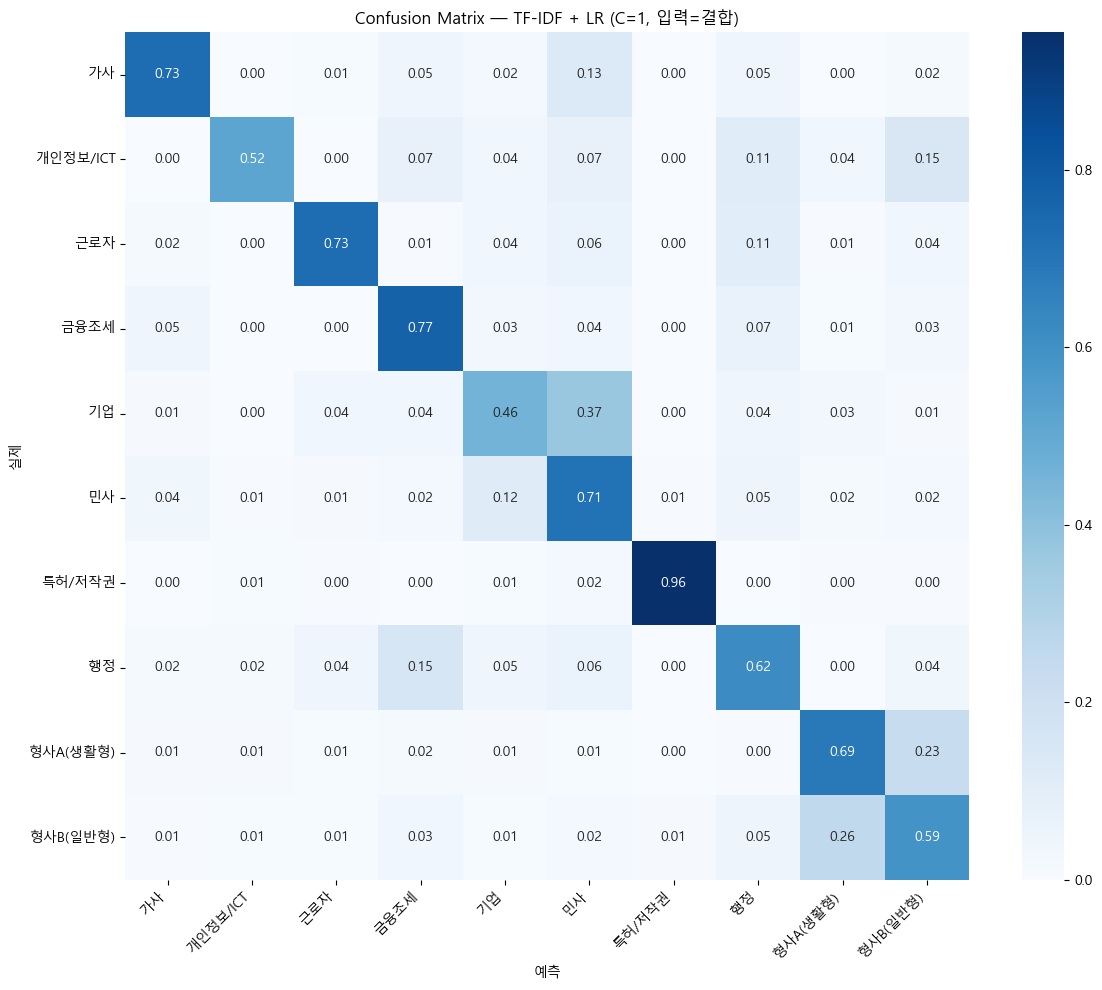

confusion_matrix_baseline.png 저장 완료


In [15]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import confusion_matrix

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 가장 좋은 모델 기준으로 Confusion Matrix
cm = confusion_matrix(test['label'], y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # 행별 정규화

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    xticklabels=label_names, yticklabels=label_names,
    annot=True, fmt='.2f', cmap='Blues'
)
plt.title(f'Confusion Matrix — TF-IDF + LR (C={best_C}, 입력={best_input_name})')
plt.xlabel('예측')
plt.ylabel('실제')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150)
plt.show()
print("confusion_matrix_baseline.png 저장 완료")